In [34]:
import os
import sys
import time
import intake
from tqdm import tqdm
import xarray as xr
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta


from dask.distributed import Client, LocalCluster

os.environ['WXSYSLIBDIR']='/g/data/gb02/mb0427/WxSysLib'
sys.path.append(os.environ['WXSYSLIBDIR'])
os.environ['SWTLIBDIR']='/home/565/mb0427/gdata-gb02/Australian_synoptic_weather_types'
sys.path.append(os.environ['SWTLIBDIR'])
os.environ['GITLIBDIR']='/home/565/mb0427/gdata-if69/GC26_energy_synoptics'
sys.path.append(os.environ['GITLIBDIR'])

from assign.assign import assign_grid_to_SWT

In [3]:
inpath='/home/565/mb0427/gdata-if69/GC26_energy_synoptics/data/output/era5_wind_drought_binary'
ds=xr.open_dataset(f'{inpath}/wind_drought_binary_wind_1980_2020.nc')

In [ ]:
SWTpath='/home/565/mb0427/gdata-gb02/Australian_synoptic_weather_types/'
clusters=xr.open_dataset(SWTpath+"SWT_climatology/SWT_climatology.nc")
clusters=clusters.sel(time=slice(datetime(1980,1,1),datetime(2020,12,31,23)))
clusters["time"] = clusters["time"] - np.timedelta64(12, "h")
SWTnames = clusters.SWTs

In [71]:
clusters=pd.read_csv(f"{SWTpath}SWT_climatology/SWT_climatology.csv")
times=[datetime.strptime(t,'%Y-%m-%d') for t in clusters.time.to_list()]
clusters['time']=times
clusters=clusters[clusters.time>=datetime(1980,1,1)]
clusters=clusters[clusters.time<=datetime(2020,12,31)]


00%|██████████| 30/30 [03:12<00:00,  6.41s/it]

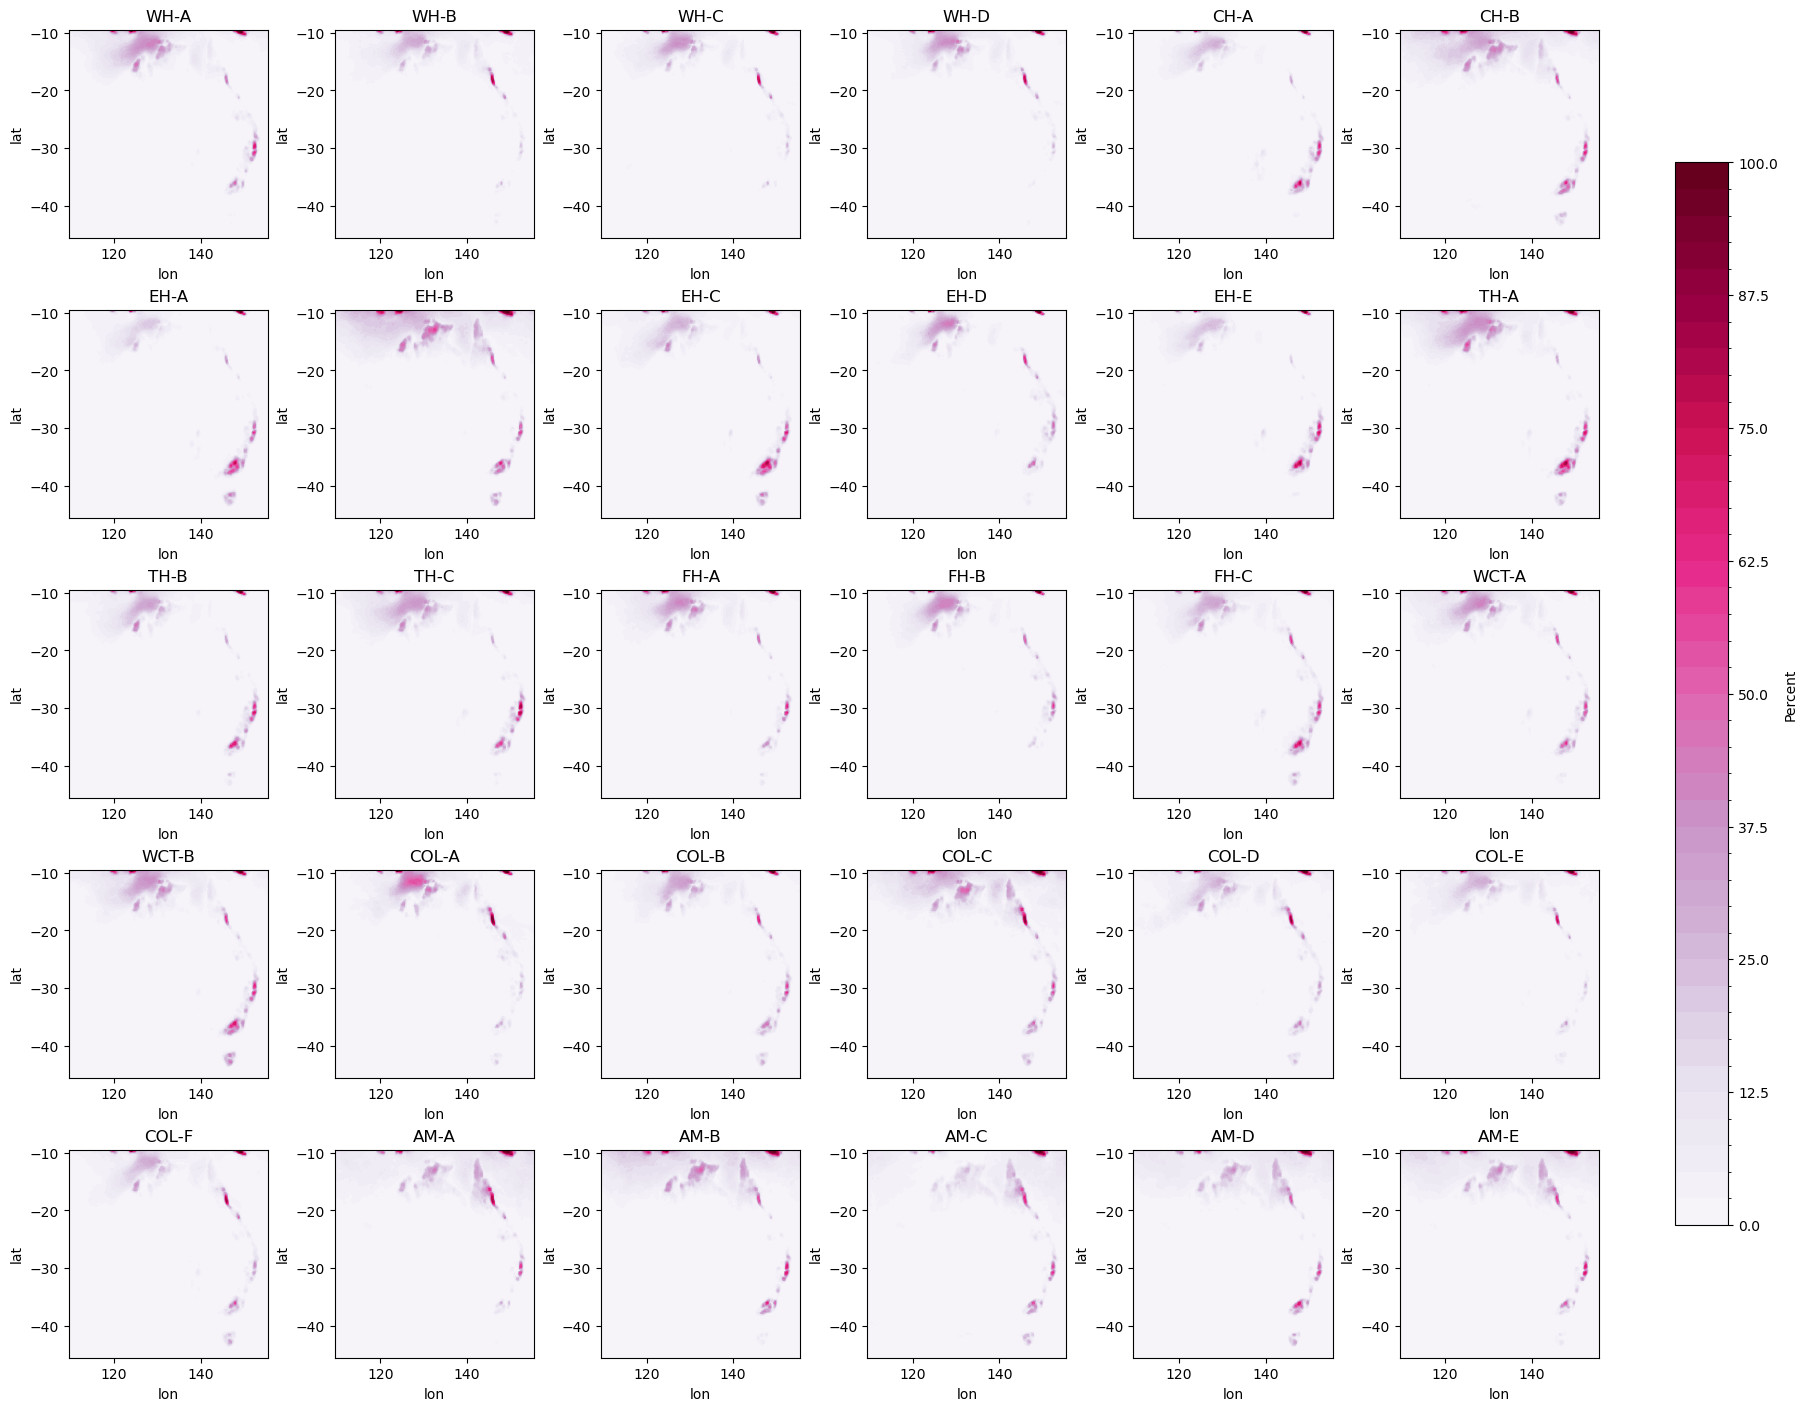

In [131]:
var = "wind_drought_lt3"
levels = np.linspace(0, 100, 41)

fig, axes = plt.subplots(5, 6, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

mappable = None

for i, SWTname in enumerate(tqdm(SWTnames)):
    SWT_i = clusters[clusters.assigned_SWT == SWTname]
    ds_i = ds.sel(time=SWT_i.time.to_list())
    ds_i_clim = (ds_i[var].sum(dim="time") / len(ds_i.time)) * 100

    ax = axes[i]
    mappable = ds_i_clim.plot.contourf(
        ax=ax,
        levels=levels,
        cmap="PuRd",
        vmin=0,
        vmax=100,
        add_colorbar=False
    )
    ax.set_title(str(SWTname.item()))

for j in range(len(SWTnames), len(axes)):
    axes[j].set_visible(False)

fig.colorbar(mappable, ax=axes, shrink=0.8, label="Percent")

outpath=os.environ['GITLIBDIR']+''
outfile=f"{outpath}/analysis/figures/regimes_{var}.png"
fig.savefig(outfile, dpi=600)
plt.show()

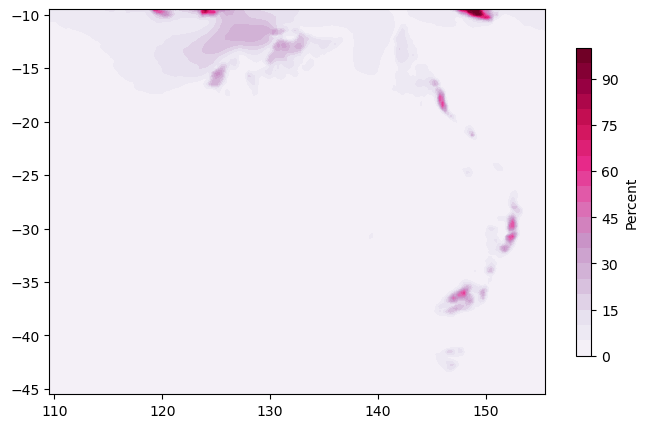

In [132]:
levels = np.linspace(0, 100, 21)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ds_clim = (ds[var].sum(dim='time')/len(ds.time))*100

cf=ax.contourf(ds_clim.lon,ds_clim.lat,ds_clim,
    levels=levels,
    cmap="PuRd"
)
#ax.set_title(str(SWTname.item()))

fig.colorbar(cf, ax=ax, shrink=0.8, label="Percent")

outpath=os.environ['GITLIBDIR']+''
outfile=f"{outpath}/analysis/figures/full_{var}.png"
fig.savefig(outfile, dpi=600)
plt.show()
